# Analysis for PsyNamic Manuscript

## Analysis of data fetching pipeline
### PubMed Fetch Results


How many articles were retrieved from PubMed via API until 31.12.2025 (with new search string)

In [63]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import pandas as pd


df = pd.read_csv("../data/pubmed_fetch_results/pubmed_results_19000101_20260530_00-03-43.csv", dtype={"pubmed_id": str})
print(f'Total articles retrieved: {len(df)}')
# check if there are any duplicates in the new pubmed fetch results based on pubmed_id
duplicates_pubmed_id = df[df.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in new pubmed fetch results based on pubmed_id: {len(duplicates_pubmed_id)}')

df_2025_pubmed_fetch_new_string = df[df["entrez_year"] < 2026]
print(f'Total articles retrieved until 2025: {len(df_2025_pubmed_fetch_new_string)}')
print(f'Total articles without abstract until 2025: {len(df_2025_pubmed_fetch_new_string[df_2025_pubmed_fetch_new_string["abstract"].isna()])}')


Total articles retrieved: 21530
Number of duplicate articles in new pubmed fetch results based on pubmed_id: 0
Total articles retrieved until 2025: 20801
Total articles without abstract until 2025: 4875


How many articles were retrieved from PubMed via API in 2026 (with old search string)

In [64]:
df = pd.read_csv("../data/pubmed_fetch_results/pubmed_results_20240105_20260320_00-00-10.csv", dtype={"pubmed_id": str})

print(f'Total articles retrieved: {len(df)}')
# check if there are any duplicates in the new pubmed fetch results based on pubmed_id
duplicates_pubmed_id = df[df.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in new pubmed fetch results based on pubmed_id: {len(duplicates_pubmed_id)}')

df_2025_pubmed_fetch = df[df["entrez_year"] < 2026]
print(f'Total articles retrieved until 2025: {len(df_2025_pubmed_fetch)}')
print(f'Total articles without abstract until 2025: {len(df_2025_pubmed_fetch[df_2025_pubmed_fetch["abstract"].isna()])}')


Total articles retrieved: 1323
Number of duplicate articles in new pubmed fetch results based on pubmed_id: 0
Total articles retrieved until 2025: 1172
Total articles without abstract until 2025: 15


In [65]:
df_2026_pubmed_fetch = df[df["entrez_year"] == 2026]
print(f'Total articles retrieved in 2026: {len(df_2026_pubmed_fetch)}')
print(f'Total articles without abstract in 2026: {len(df_2026_pubmed_fetch[df_2026_pubmed_fetch["abstract"].isna()])}')

Total articles retrieved in 2026: 151
Total articles without abstract in 2026: 1


In [ ]:
from data.get_pubmed_data import get_pubmed_id_from_title
from tqdm import tqdm


as_file = "../data/manual/as_review_studies_relevant_with_info_20240101_00-00-00.csv"
df_as_relevant = pd.read_csv(as_file)
# count how many articles don't have a pubmed_id
num_missing_pubmed_id = df_as_relevant['pubmed_id'].isna().sum()
print(f'Number of articles in ASreview dataset without pubmed_id: {num_missing_pubmed_id}')


# improve pubmedid matching
for idx, row in tqdm(df_as_relevant.iterrows(), total=len(df_as_relevant)):
    pubmed_id = row['pubmed_id']
    if pd.isna(pubmed_id):
        pubmed_id = get_pubmed_id_from_title(row['title'])
        if pubmed_id:
            df_as_relevant.at[idx, 'pubmed_id'] = pubmed_id
            df_as_relevant.at[idx, 'pubmed_url'] = f'https://pubmed.ncbi.nlm.nih.gov/{pubmed_id}/'

# check again how many articles don't have a pubmed_id
num_missing_pubmed_id = df_as_relevant['pubmed_id'].isna().sum()
print(f'Number of articles in ASreview dataset without pubmed_id after matching: {num_missing_pubmed_id}')

# write back to csv
df_as_relevant.to_csv("../data/manual/as_review_studies_relevant_with_info_20240101_00-00-00.csv", index=False)




In [114]:
as_file = "../data/manual/as_review_studies_relevant_with_info_20240101_00-00-00.csv"
df_as_relevant = pd.read_csv(as_file)
# convert pubmed_id to from float to int and then to string, while keeping NaN values as is
df_as_relevant['pubmed_id'] = df_as_relevant['pubmed_id'].apply(lambda x: str(int(x)) if pd.notna(x) else x)    

duplicates_as_relevant_pubmed_id = df_as_relevant[df_as_relevant.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in ASreview dataset based on pubmed_id: {len(duplicates_as_relevant_pubmed_id)}')

# print sorted duplicates (title + pubmedId) based on pubmed_id, where pubmed_id is not null
print(duplicates_as_relevant_pubmed_id.sort_values(by="pubmed_id")[["title", "pubmed_id"]].dropna())


Number of duplicate articles in ASreview dataset based on pubmed_id: 925
                                                  title pubmed_id
162   Psilocybin can occasion mystical-type experien...  16826400
165   Psilocybin can occasion mystical-type experien...  16826400
2117  Effects of nicotine on the neurophysiological ...  24478731
2119  Effects of nicotine on the neurophysiological ...  24478731
34    LSD Acutely Impairs Fear Recognition and Enhan...  27249781
52    LSD acutely impairs fear recognition and enhan...  27249781
808   Ketamine for treatment of mood disorders and s...  35166663
812   Ketamine for treatment of mood disorders and s...  35166663


Are there any duplicates in the 2025 PubMed API data? Or in the ASreview retrieved dataset?

In [117]:
mask = df_as_relevant['pubmed_id'].notna()

duplicates = df_as_relevant[
    mask &
    df_as_relevant.duplicated(subset=['pubmed_id'], keep=False)
]

print(f"Number of duplicate articles in ASreview dataset (excluding NaN): {len(duplicates)}")
duplicates_no_nan = df_2025_pubmed_fetch[df_2025_pubmed_fetch.duplicated(subset=['pubmed_id'], keep=False) & df_2025_pubmed_fetch['pubmed_id'].notnull()]
print(f'Number of duplicate articles in 2025 PubMed API dataset: {len(duplicates_no_nan)}')

duplicates_new_string = df_2025_pubmed_fetch_new_string[df_2025_pubmed_fetch_new_string.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in 2025 PubMed API dataset with new string: {len(duplicates_new_string)}')


Number of duplicate articles in ASreview dataset (excluding NaN): 8
Number of duplicate articles in 2025 PubMed API dataset: 0
Number of duplicate articles in 2025 PubMed API dataset with new string: 0


### Relevant Studies from PubMed API
How many articles were classified relevant from PubMed API data until 31.12.2025 (old string)?

In [102]:
df_rel = pd.read_csv("../data/relevant_studies/studies_20260320_00-09-37.csv")
df_rel_2025 = df_rel[df_rel["entrez_year"] <= 2025]
print(f'Total articles until 2025: {len(df_rel_2025)}')
df_rel_2025_incl = df_rel_2025[df_rel_2025["prediction"] == 1]
print(f'Total articles classified relevant until 2025: {len(df_rel_2025_incl)}')
print(f'Total articles classified irrelevant until 2025: {len(df_rel_2025[df_rel_2025["prediction"] == 0])}')


Total articles until 2025: 1157
Total articles classified relevant until 2025: 634
Total articles classified irrelevant until 2025: 523


How many articles were classified relevant from PubMed API data until 31.12.2025 (new string)?

In [103]:
df_rel_new_string = pd.read_csv('../data/relevant_studies/studies_20260530_02-04-42.csv', dtype={"pubmed_id": str})
df_rel_2025_new = df_rel_new_string[df_rel_new_string["entrez_year"] <= 2025]
df_rel_2025_new_incl = df_rel_2025_new[df_rel_2025_new["prediction"] == 1]
df_rel_2025_new_excl = df_rel_2025_new[df_rel_2025_new["prediction"] == 0]
print(f'Total articles classified relevant until 2025: {len(df_rel_2025_new_incl)}')
print(f'Total articles classified irrelevant until 2025: {len(df_rel_2025_new_excl)}')

Total articles classified relevant until 2025: 4571
Total articles classified irrelevant until 2025: 11355


Are there any samples determined as relevant from new Pubmed search which were manually determined as irrelevant (not irrelevant after stopping criteria)? (action required, remove them from merged database)

In [ ]:
from tqdm import tqdm

def read_in_asreview() -> list[pd.DataFrame]:
    input_file = "/home/veral/PsyNamic/data/raw_data/asreview_dataset_all_Psychedelic Study.csv"
    df = pd.read_csv(input_file)
    df['title'] = df['title'].str.lower()
    included = df[df['included'] == 1]
    excluded = df[df['included'] == 0]
    excluded_after_stopping = df[df['included'].isna()]

    return [included, excluded, excluded_after_stopping, df]

_, excluded, excluded_after_stopping, _ = read_in_asreview()
excluded['pubmed_id'] = None
for idx, row in tqdm(excluded.iterrows(), total=len(excluded)):
    title = row['title']
    pubmed_id = get_pubmed_id_from_title(title)
    excluded.at[idx, 'pubmed_id'] = pubmed_id

excluded.to_csv("../data/manual/excluded_with_pubmed_id.csv", index=False)

for idx, row in tqdm(excluded_after_stopping.iterrows(), total=len(excluded_after_stopping)):
    title = row['title']
    pubmed_id = get_pubmed_id_from_title(title)
    excluded_after_stopping.at[idx, 'pubmed_id'] = pubmed_id

excluded_after_stopping.to_csv("../data/manual/excluded_after_stopping_with_pubmed_id.csv", index=False)  



Number of overlaps between ASReview included and irrelevant studies until 2025 (pubmed_id): 126
Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): 2126


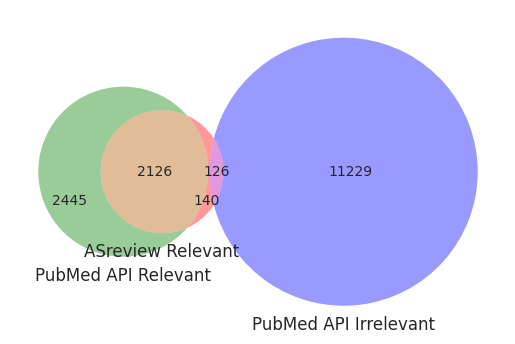

In [104]:
from analysis import compare_dfs
from matplotlib_venn import venn3


excluded = pd.read_csv("../data/manual/as_review_studies_excluded_with_pubmed_id.csv", dtype={"pubmed_id": str})
excluded_after_stopping = pd.read_csv("../data/manual/as_review_studies_excluded_after_stopping_with_pubmed_id.csv", dtype={"pubmed_id": str})



nr, matches = compare_dfs(df_as_relevant, df_rel_2025_new_excl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview included and irrelevant studies until 2025 (pubmed_id): {nr}')
nr, matches = compare_dfs(df_as_relevant, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): {nr}')

sets = [
    set(df_as_relevant['pubmed_id'].dropna()),
    set(df_rel_2025_new_incl['pubmed_id'].dropna()),
    set(df_rel_2025_new_excl['pubmed_id'].dropna()),

]
v = venn3(sets,    
      ['ASreview Relevant', 'PubMed API Relevant', 'PubMed API Irrelevant'])

# move 3. and 4. label down
v.get_label_by_id('100').set_y(-0.1)
v.get_label_by_id('010').set_y(-0.1)

Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): 41
Number of overlaps between ASReview excluded after stopping and relevant studies until 2025 (pubmed_id): 63


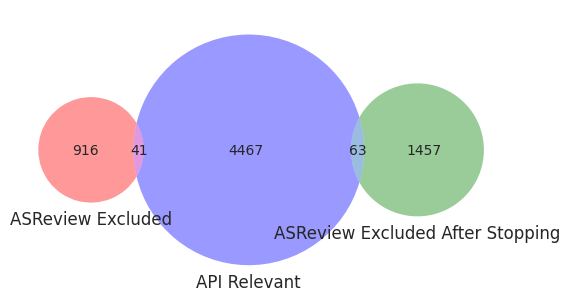

In [105]:
nr, matches_excluded = compare_dfs(excluded, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): {nr}')

nr, matches_excluded_after_stopping = compare_dfs(excluded_after_stopping, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview excluded after stopping and relevant studies until 2025 (pubmed_id): {nr}')

sets = [
    set(excluded['pubmed_id'].dropna()),
    set(excluded_after_stopping['pubmed_id'].dropna()),
    set(df_rel_2025_new_incl['pubmed_id'].dropna())
]
venn3(sets, ['ASReview Excluded', 'ASReview Excluded After Stopping', 'API Relevant'])


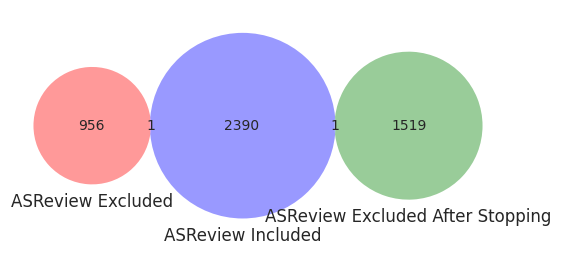

In [106]:
sets = [
    set(excluded['pubmed_id'].dropna()),
    set(excluded_after_stopping['pubmed_id'].dropna()),
    set(df_as_relevant['pubmed_id'].dropna())
]

venn3(sets, ['ASReview Excluded', 'ASReview Excluded After Stopping', 'ASReview Included'])

How many articles from classified as relevant from PubMed API data until 31.12.2025 (new string) which are in the ASReview included dataset?

In [107]:
nr, matches = compare_dfs(df_as_relevant, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): {nr}')
print(matches["pubmed_id_df1"].nunique())
vc = matches["pubmed_id_df1"].value_counts()


duplicated_ids = vc[vc > 1]
print(duplicated_ids)

Number of overlaps between ASReview included and relevant studies until 2025 (pubmed_id): 2126
2126
pubmed_id_df1
27249781    2
16826400    2
35166663    2
Name: count, dtype: int64


How many articles of the api results with the new search string were already included in the dataset of the old search string?

In [108]:
nr, matches = compare_dfs(df_rel_2025_incl, df_rel_2025_new_incl, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between relevant studies until 2025 with old and new string (pubmed_id): {nr}')

Number of overlaps between relevant studies until 2025 with old and new string (pubmed_id): 628


Are there any sample determined as not relevant from new Pubmed search which were manually determined as relevant? (no action required because they are in AS database)

In [109]:
nr, matches = compare_dfs(df_rel_2025_new_excl, df_as_relevant, ['pubmed_id'], ['pubmed_id'])
print(f'Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): {nr}')



Number of overlaps between ASReview excluded and relevant studies until 2025 (pubmed_id): 126


### Total relevant studies up until 31.12.2025


In [ ]:
# ------------------------------------------------------------------
# Summary of input datasets
# ------------------------------------------------------------------

print("\n=== INPUT DATASETS ===")
print(f"ASReview relevant articles:           {len(df_as_relevant):,}")
print(f"PubMed API relevant articles (2025):  {len(df_rel_2025_new_incl):,}")

# ------------------------------------------------------------------
# Define exclusion sets
# ------------------------------------------------------------------

# drop duplicates only among valid pubmed_ids, keep NaNs as-is
df_as_relevant = pd.concat([
    df_as_relevant[~mask],  # keep all NaN / empty pubmed_id rows unchanged
    df_as_relevant[mask].drop_duplicates(subset=['pubmed_id'], keep='first')
])
excluded_ids = set(excluded["pubmed_id"].dropna())
excluded_after_stopping_ids = set(excluded_after_stopping["pubmed_id"].dropna())
all_excluded_ids = excluded_ids | excluded_after_stopping_ids

asreview_ids = set(df_as_relevant["pubmed_id"].dropna())

print("\n=== EXCLUSION SETS ===")
print(f"Excluded articles:                    {len(excluded_ids):,}")
print(f"Excluded after stopping:              {len(excluded_after_stopping_ids):,}")
print(f"Total unique excluded PubMed IDs:     {len(all_excluded_ids):,}")

Number of duplicate pubmed_ids in ASReview relevant dataset: 0

=== INPUT DATASETS ===
ASReview relevant articles:           3,309
PubMed API relevant articles (2025):  4,571

=== EXCLUSION SETS ===
Excluded articles:                    957
Excluded after stopping:              1,520
Total unique excluded PubMed IDs:     2,477


In [77]:

df_v1 = df_rel_2025_new_incl.copy()

# --------------------------------------------------
# STEP 1: remove ASReview overlap
# --------------------------------------------------
overlap_asreview = set(df_v1["pubmed_id"].dropna()) & asreview_ids

df_v1_1 = df_v1[~df_v1["pubmed_id"].isin(overlap_asreview)].copy()

print("STEP 1: Remove ASReview overlap")
print(f"Overlap removed: {len(overlap_asreview):,}")
print(f"Remaining:       {len(df_v1_1):,}")

# --------------------------------------------------
# STEP 2: remove excluded IDs
# --------------------------------------------------
overlap_excluded = set(df_v1_1["pubmed_id"].dropna()) & all_excluded_ids

df_v1_final = df_v1_1[~df_v1_1["pubmed_id"].isin(all_excluded_ids)].copy()

print("\nSTEP 2: Remove excluded IDs")
print(f"Excluded removed: {len(overlap_excluded):,}")
print(f"Remaining:        {len(df_v1_final):,}")

# --------------------------------------------------
# MERGE
# --------------------------------------------------
merged_v1 = pd.concat([df_as_relevant, df_v1_final], ignore_index=True)

print("\nFINAL RESULT (VARIANT 1)")
print(f"PubMed final: {len(df_v1_final):,}")
print(f"ASReview:    {len(df_as_relevant):,}")
print(f"Merged:      {len(merged_v1):,}")

STEP 1: Remove ASReview overlap
Overlap removed: 2,126
Remaining:       2,445

STEP 2: Remove excluded IDs
Excluded removed: 103
Remaining:        2,342

FINAL RESULT (VARIANT 1)
PubMed final: 2,342
ASReview:    3,313
Merged:      5,655


In [ ]:
df_v2 = df_rel_2025_new_incl.copy()

# --------------------------------------------------
# STEP 1: remove excluded IDs
# --------------------------------------------------
overlap_excluded = set(df_v2["pubmed_id"].dropna()) & all_excluded_ids

df_v2_1 = df_v2[~df_v2["pubmed_id"].isin(all_excluded_ids)].copy()

print("STEP 1: Remove excluded IDs")
print(f"Excluded removed: {len(overlap_excluded):,}")
print(f"Remaining:        {len(df_v2_1):,}")

# --------------------------------------------------
# STEP 2: remove ASReview overlap
# --------------------------------------------------
overlap_asreview = set(df_v2_1["pubmed_id"].dropna()) & asreview_ids

df_v2_final = df_v2_1[~df_v2_1["pubmed_id"].isin(overlap_asreview)].copy()

print("\nSTEP 2: Remove ASReview overlap")
print(f"Overlap removed: {len(overlap_asreview):,}")
print(f"Remaining:       {len(df_v2_final):,}")

# --------------------------------------------------
# MERGE
# --------------------------------------------------
merged_v2 = pd.concat([df_as_relevant, df_v2_final], ignore_index=True)

print("\nFINAL RESULT (VARIANT 2)")
print(f"PubMed final: {len(df_v2_final):,}")
print(f"ASReview:    {len(df_as_relevant):,}")
print(f"Merged:      {len(merged_v2):,}")

# Write merged dataset to csv
merged_v2.to_csv("/home/veral/PsyNamic/PsyNamic-Webapp/data/merged_datasets/merged_pubmed_asreview_20260320_00-00-00.csv", index=False)

STEP 1: Remove excluded IDs
Excluded removed: 104
Remaining:        4,467

STEP 2: Remove ASReview overlap
Overlap removed: 2,125
Remaining:       2,342

FINAL RESULT (VARIANT 2)
PubMed final: 2,342
ASReview:    3,313
Merged:      5,655


Are there duplicates in merged dataset?

In [122]:
# mask for valid pubmed_ids only
valid_mask = merged_v2['pubmed_id'].notna()
nr_duplicates = merged_v2[valid_mask]['pubmed_id'].duplicated().sum()
print(f"Number of duplicate pubmed_ids in ASReview relevant dataset: {nr_duplicates}")

# check how many duplicates are in merged_df based on same title and year, not considerin year NaN
duplicates_merged = merged_v2[merged_v2.duplicated(subset=['title', 'year'], keep=False) & merged_v2['year'].notna()]
print(f'Number of duplicate articles in merged dataset based on title and year: {len(duplicates_merged)}')
# print those duplicates
print(duplicates_merged[['id', 'title', 'year', 'pubmed_id']])


# check how many duplicates based on title only
duplicates_title = merged_v2[merged_v2.duplicated(subset=['title'], keep=False)]
print(f'Number of duplicate articles in merged dataset based on title only: {len(duplicates_title)}')
print(duplicates_title[['id', 'title', 'year', 'pubmed_id']])

# write duplicates to csv
duplicates_title.to_csv("../analysis/duplicates_title.csv", index=False)

IndexError: invalid index to scalar variable.

Do the numbers add up to the PsyNamic Webapp dashboard?

In [ ]:
df_rel_2026_new = df_rel_new_string[
    (df_rel_new_string["entrez_year"] > 2025) &
    (df_rel_new_string["prediction"] == 1)
]
print(f'Total articles classified relevant in 2026: {len(df_rel_2026_new)}')

len(merged_v2)+len(df_rel_2026_new)

Total articles classified relevant in 2026: 245


5900

Write the filtered up to 2025 plus the 2026 relevant articles in a new csv file.

In [82]:
rel_api_2026 = pd.concat([df_v2_final, df_rel_2026_new], ignore_index=True)
print(f'Total relevant articles in 2026: {len(df_rel_2026_new)}')
print(f'Total relevant articles in 2026 (including those from 2025): {len(rel_api_2026)}')

rel_api_2026.to_csv("../data/manual/studies_relevant_deduplicated_excluded_20260601.csv", index=False)

Total relevant articles in 2026: 245
Total relevant articles in 2026 (including those from 2025): 2587


## Analysis of predictions
### Classification predictions

In [84]:
merged_df = merged_v2.copy()
merged_df.head()

,id,text,type_of_reference,name_of_database,number,keywords,language,notes,year,start_page,...,asreview_prior,exported_notes_1,included,asreview_ranking,pubmed_url,pubmed_id,prediction,probability,pub_date,entrez_year
0,6152,Ketamine Versus Midazolam for Recurrence of Su...,JOUR,NaN,NaN,"['Depression', 'Ketamine', 'Midazolam', 'Recur...",NaN,[],2020.0,NaN,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,8321,Acute effects of MDMA and LSD co-administratio...,JOUR,NaN,13,"['Male', 'Humans', 'Female', '*N-Methyl-3,4-me...",eng,"['1740-634x', 'Straumann, Isabelle', 'Ley, Lau...",2023.0,1840-1848,...,1.0,NaN,1.0,2.0,https://pubmed.ncbi.nlm.nih.gov/37258715/,37258715,NaN,NaN,NaN,NaN
2,1264,Trial of Psilocybin versus Escitalopram for De...,JOUR,NaN,15,"['Adult', 'Antidepressive Agents/adverse effec...",eng,"['1533-4406', 'Carhart-Harris, Robin', 'Giriba...",2021.0,1402-1411,...,1.0,NaN,1.0,3.0,https://pubmed.ncbi.nlm.nih.gov/33852780/,33852780,NaN,NaN,NaN,NaN
3,7738,Acute autonomic and psychotropic effects of LS...,JOUR,NaN,4,"['*European', '*controlled study', '*human', '...",NaN,[],2015.0,359,...,0.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4,3640,"Distinct acute effects of LSD, MDMA, and D-amp...",JOUR,NaN,3,"['Adult', 'Affect/drug effects/physiology', 'C...",eng,"['1740-634x', 'Holze, Friederike', 'Orcid: 000...",2020.0,462-471,...,0.0,NaN,1.0,5.0,https://pubmed.ncbi.nlm.nih.gov/31733631/,31733631,NaN,NaN,NaN,NaN


In [85]:
class_data = pd.read_csv("../analysis/export/classification_data.csv")
ner_data = pd.read_csv("../analysis/export/ner_data.csv")
dosage_ner_data = pd.read_csv("../analysis/export/dosage_data.csv")
study_data = pd.read_csv("../analysis/export/study_data.csv")

# check if all ids of merged_df are in study_data
ids_merged = set(merged_df['id'].tolist())
ids_study_data = set(study_data['study_id'].tolist())
ids_not_in_study_data = ids_merged - ids_study_data
print(f'Number of ids in merged dataset that are not in study_data: {len(ids_not_in_study_data)}')
print(f'Number of ids in study_data that are not in merged dataset: {len(ids_study_data - ids_merged)}')

# Only keep rows in study_data where study_id is in merged_df
study_data_2025 = study_data[study_data['study_id'].isin(ids_merged)].reset_index(drop=True)
print(len(study_data_2025))

class_data_2025 = class_data[class_data['study_id'].isin(ids_merged)].reset_index(drop=True)
ner_data_2025 = ner_data[ner_data['study_id'].isin(ids_merged)].reset_index(drop=True)
dosage_ner_data_2025 = dosage_ner_data[dosage_ner_data['Study_ID'].isin(ids_merged)].reset_index(drop=True)


Number of ids in merged dataset that are not in study_data: 0
Number of ids in study_data that are not in merged dataset: 2458
5655


In [ ]:
class_data_2025.head()

,study_id,task,label,probability,model,is_multilabel
0,305,Condition,Psychiatric condition,1.0,manual_annotation,True
1,305,Condition,Depression,1.0,manual_annotation,True
2,2483,Condition,Healthy Participants,1.0,manual_annotation,True
3,2832,Condition,Recreational Drug Use,1.0,manual_annotation,True
4,2832,Condition,Healthy Participants,1.0,manual_annotation,True


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df = class_data_2025.copy()
# Count studies per task per label
label_counts = df.groupby(['task', 'label'])['study_id'].nunique().reset_index(name='count')

# Get list of unique tasks
tasks = label_counts['task'].unique()
n_tasks = len(tasks)

# Create subplots: one row per task
fig = make_subplots(
    rows=n_tasks, cols=1,
    shared_xaxes=False,  # each task has its own x-axis
    vertical_spacing=0.02,
    subplot_titles=tasks
)

# Add a bar for each task
for i, task in enumerate(tasks, 1):
    task_data = label_counts[label_counts['task'] == task]
    fig.add_trace(
        go.Bar(
            x=task_data['count'],
            y=task_data['label'],
            orientation='h',
            text=task_data['count'],
            textposition='inside',
            showlegend=False
        ),
        row=i, col=1
    )

# Update layout for A4 landscape style
fig.update_layout(
    height=250*n_tasks,  # scale height based on number of tasks
    width=1000,
    title="Label Distribution per Task",
    template="plotly_white"
)

fig.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from style.colors import get_color_mapping
import numpy as np

# Count studies per task per label
label_counts = df.groupby(['task', 'label'])['study_id'].nunique().reset_index(name='count')

# Compute total studies per task for percentages
task_totals = label_counts.groupby('task')['count'].sum().reset_index(name='total')
label_counts = label_counts.merge(task_totals, on='task')
label_counts['percent'] = (label_counts['count'] / label_counts['total'] * 100).round(1)

tasks = label_counts['task'].unique()
n_tasks = len(tasks)
vertical_spacing = min(0.04, 1/(n_tasks-1))

# Create subplots
fig = make_subplots(
    rows=n_tasks, cols=1,
    shared_xaxes=False,
    vertical_spacing=vertical_spacing,
    subplot_titles=tasks,
    row_heights=[0.8]*n_tasks  # leave room for legends
)

# Add bars + mini-legend per task
for i, task in enumerate(tasks, 1):
    task_data = label_counts[label_counts['task'] == task].copy()
    task_data = task_data.sort_values(by='count', ascending=False)
    
    labels_list = task_data['label'].tolist()
    color_map = get_color_mapping(task, labels_list, type='rgb')
    
    # Add stacked bars
    for idx, row in task_data.iterrows():
        fig.add_trace(
            go.Bar(
                y=[task],
                x=[row['count']],
                name=row['label'],
                orientation='h',
                text=f"{row['count']} ({row['percent']}%)",
                textposition='inside',
                marker_color=color_map[row['label']],
                showlegend=False
            ),
            row=i, col=1
        )
    
    # Add mini-legend using Scatter traces
    total_width = sum(task_data['count']) * 1.1
    x_positions = np.linspace(0, total_width, len(labels_list))
    
    for x, lbl in zip(x_positions, labels_list):
        fig.add_trace(
            go.Scatter(
                x=[x],
                y=[-1],  # below bars, outside visible axis
                mode='markers+text',
                marker=dict(color=color_map[lbl], size=15, symbol='square'),
                text=[lbl],
                textposition='middle right',
                showlegend=False,
                hoverinfo='none'
            ),
            row=i, col=1
        )

# Hide all y-axis ticks for mini-legend and remove extra space
fig.update_yaxes(automargin=True, showticklabels=True)  # main bars visible
fig.update_xaxes(showticklabels=False)

# Make sure negative y values (for legend) do not show axis
fig.update_layout(
    barmode='stack',
    height=300*n_tasks,
    width=1000,
    title="Stacked Bar Chart with Mini-Legends per Task",
    template="plotly_white",
    margin=dict(t=100, b=100),
)

fig.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from style.colors import GREY, BROWN, BLUE

SKIP_TASKS = ['Clinical Trial Phase', 'Study Conclusion']

TASK_ORDER_GROUP = [
    ['Study Type', 'Data Type', 'Data Collection', 'Number of Participants', 'Sex of Participants', 'Age of Participants', 'Study Purpose', 'Study Control'],
    ['Substances', 'Application Form', 'Regimen', 'Setting', 'Substance Naivety'],
    ['Condition', 'Outcomes']
]

GROUPS = ['Study characteristics', 'Substances','Clinical Measures']

df = class_data_2025.copy()


def build_pallette(task, labels_list):
    
    palette = {}
    if 'Unknown' in labels_list:
        palette['Unknown'] = mcolors.to_hex(GREY)
    if 'Not applicable' in labels_list:
        palette['Not applicable'] = mcolors.to_hex(BROWN)
    if 'Other' in labels_list:
        palette['Other'] = mcolors.to_hex(BLUE)
    
    remaining_labels = [l for l in labels_list if l not in palette]

    sns_palette = (
        sns.color_palette("hls", len(remaining_labels))
        if len(remaining_labels) > 10
        else sns.color_palette("tab10", len(remaining_labels))
    )

    for color, lbl in zip(sns_palette, remaining_labels):
        palette[lbl] = mcolors.to_hex(color)
    return palette


def stacked_bar_plot(df, tasks, groups, skip_tasks=SKIP_TASKS, shared_x=True, outdir: str=None, merge_dict: dict=None):
    if merge_dict:
        for task, repl_dict in merge_dict.items():
            for new_label, old_labels in repl_dict.items():
                for label in old_labels:
                    df.loc[
                        (df['task'] == task) & (df["label"] == label),
                        "label"
                    ] = new_label
    
    label_counts = df.groupby(['task', 'label'])['study_id'].nunique().reset_index(name='count')
    total_nr_studies = len(df['study_id'].unique())

    task_totals = label_counts.groupby('task')['count'].sum().reset_index(name='total')
    label_counts = label_counts.merge(task_totals, on='task')
    label_counts['percent'] = (label_counts['count'] / total_nr_studies * 100).round(1)


    SMALL_THR = 350
    TINY_THR = 50

    for group_name, (_, group_tasks) in zip(GROUPS, enumerate(TASK_ORDER_GROUP)):

        group_df = label_counts[label_counts['task'].isin(group_tasks)].copy()
        max_total = group_df['total'].max() 

        # keep only tasks that exist in your data
        group_tasks_present = [t for t in group_tasks if t in group_df['task'].unique()]
        n_tasks_group = len(group_tasks_present)        

        fig, axes = plt.subplots(
            n_tasks_group,
            1,
            figsize=(12, 2.5 * n_tasks_group),
            sharex=shared_x,
            gridspec_kw={'hspace': 0.5}
        )
    

        for ax, task in zip(axes, group_tasks_present):
           
            task_data = group_df[group_df['task'] == task].copy()
            task_data = task_data.sort_values(by='count', ascending=False).reset_index(drop=True)
            
            total = task_data['count'].sum()
            labels_list = task_data['label'].tolist()
            palette = build_pallette(task, labels_list)
            LINE_LEN = 0.01 * total
            TEXT_GAP = 0.005 * total


            left = 0
            bars = []
            legend_labels = []

            label_idx = 0
            tiny_idx = 0

            tiny_mask = task_data['count'] < TINY_THR
            tiny_total = tiny_mask.sum()
            tiny_y_positions = (
                np.linspace(0.3 / 2 - 0.05, -0.3 / 2 + 0.05, tiny_total + 1)
                if tiny_total > 0 else []
            )

            small_maks = task_data['count'] < SMALL_THR
            n_small = small_maks.sum() - tiny_total

            y_top = [0.25, 0.20, 0.15]
            y_bottom = [-0.25, -0.20, -0.15]

            if n_small < 3:
                y_top = y_top[-n_small:]
            elif n_small > 3 and n_small < 6:
                y_bottom = y_bottom[-n_small+3:]

            for _, row in task_data.iterrows():
                width = row['count']

                bar = ax.barh(
                    y=0,
                    width=width,
                    left=left,
                    height=0.2,
                    color=palette[row['label']],
                    edgecolor='white'
                )

                bars.append(bar[0])
                legend_labels.append(row['label'])

                x_center = left + width / 2

                if width < SMALL_THR:
                    text = f"{row['count']} ({row['percent']}%)"

                    if width > TINY_THR:

                        group = (label_idx // 3) % 2
                        pos_in_group = label_idx % 3

                        y_pos = y_top[pos_in_group] if group == 0 else y_bottom[pos_in_group]

                        line_end_x = x_center + LINE_LEN
                        text_x = line_end_x + TEXT_GAP

                        ax.plot([x_center, x_center], [0, y_pos], color='black', lw=1)
                        ax.plot([x_center, line_end_x], [y_pos, y_pos], color='black', lw=1)

                        ax.text(text_x, y_pos, text, ha='left', va='center', fontsize=9)

                        label_idx += 1

                    else:
                        if tiny_total > 0:
                            y_pos = tiny_y_positions[tiny_idx]

                            line_end_x = left + LINE_LEN
                            text_x = line_end_x + TEXT_GAP

                            ax.plot([x_center, line_end_x], [y_pos, y_pos], color='black', lw=1)

                            ax.text(text_x, y_pos, text, ha='left', va='center', fontsize=9)

                            tiny_idx += 1

                else:
                    text = f"{row['count']}\n({row['percent']}%)"
                    ax.text(x_center, 0, text, ha='center', va='center', fontsize=9)

                left += width
                
            seen = set()
            ordered = [(b, l) for b, l in zip(bars, legend_labels) if not (l in seen or seen.add(l))]

            bars, legend_labels = zip(*ordered)

            ax.set_ylim(-0.3, 0.3)
            ax.set_yticks([])
            ax.set_ylabel(task.replace(' ', '\n'), rotation=0, labelpad=40, fontsize=12, va='center')
            
            # --- compute axis range ---
            if shared_x:
                upper = int(np.ceil(max_total / 1000.0)) * 1000
            else:
                upper = int(np.ceil(total / 1000.0)) * 1000

            ticks = np.arange(0, upper + 1, 1000)

            # --- apply axis formatting ---
            if shared_x:
                ax.set_xlim(0, upper)
                ax.set_xticks(ticks)
                ax.tick_params(axis='x', which='both', labelbottom=False, bottom=False)
            else:
                ax.set_xlim(0, upper)
                ax.set_xticks(ticks)
                ax.set_xticklabels([int(x) for x in ticks])
                ax.tick_params(axis='x', which='both', labelbottom=True, bottom=True)
                    
                ax.spines['right'].set_visible(False)

            # check max length of labels
            if any(len(lbl) > 15 for lbl in labels_list):
                ncol = 4
            elif any(len(lbl) > 12 for lbl in labels_list):
                ncol = 6
            else:
                ncol = 7

            legend = ax.legend(
                bars,
                legend_labels,  # different per plot
                # title='Labels',
                loc='lower center',  # anchor point
                # bbox_to_anchor=(0, 0, 1, 0.1),  # (x0, y0, width, height)
                bbox_to_anchor = (0, 1, 1, 0.1),  # (x_center, y_top, width, height)
                mode='expand',  # makes legend stretch horizontally
                ncol=ncol,
                frameon=False,
                shadow=False,
                facecolor='white',
                edgecolor='white',
                # sett padding to the bottom
                columnspacing=0.5,
                # paddint to only the top
                borderpad=0.5,
                borderaxespad=0.0
            )

        
        for a in axes:
            a.set_xticks(ticks)
            a.tick_params(axis='x', which='both', labelbottom=False, bottom=False)


        axes[-1].tick_params(axis='x', which='both', labelbottom=True, bottom=False)
        axes[-1].set_xlabel('Number of studies')

        plt.suptitle(f"{group_name}", fontsize=14)
        if outdir:
            plt.savefig(f'{outdir}/{group_name.lower().replace(' ', '_')}_stackedbar.png', bbox_inches='tight', dpi=300)
            plt.close()
        else:
            plt.show()

In [ ]:
print(df)

stacked_bar_plot(df, TASK_ORDER_GROUP, GROUPS, shared_x=False, outdir='plots')
merge_dict = {
    'Substances': {
        'Ketamine': ['S-Ketamine', 'R-Ketamine', 'Ketamine']
    }
}
stacked_bar_plot(df, TASK_ORDER_GROUP, GROUPS, shared_x=False, outdir='plots', merge_dict=merge_dict)


        study_id              task                  label  probability  \
0            305         Condition  Psychiatric condition     1.000000   
1            305         Condition             Depression     1.000000   
2           2483         Condition   Healthy Participants     1.000000   
3           2832         Condition  Recreational Drug Use     1.000000   
4           2832         Condition   Healthy Participants     1.000000   
...          ...               ...                    ...          ...   
121525  40224581  Study Conclusion               Positive     0.497278   
121526  40046727  Study Conclusion         Not Applicable     0.037888   
121527  40047007  Study Conclusion         Not Applicable     0.061268   
121528  40656221  Study Conclusion         Not Applicable     0.121751   
121529  40656230  Study Conclusion         Not Applicable     0.048712   

                    model  is_multilabel  
0       manual_annotation           True  
1       manual_annotation

In [ ]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter


def upset_plot(df, task, outfile: str=None):

    df = class_data_2025[class_data_2025['task'] == task].copy()

    memberships = (
        df.groupby("study_id")["label"]
        .apply(lambda x: [str(i) for i in x.dropna().unique()])
    )

    upset_data = from_memberships(memberships)

    upset_data = upset_data.groupby(level=upset_data.index.names).sum()
    upset_data = upset_data.astype(int)

    plot = UpSet(
        upset_data,
        subset_size="sum",
        sort_by='cardinality',
        show_counts=False
    ).plot()

       # --- Add manual annotations ---
    ax_intersections = plot["intersections"]

    for bar in ax_intersections.patches:
        height = bar.get_height()
        if height > 0:
            ax_intersections.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # Optional: label the "totals" bars (left-side set sizes)
    if "totals" in plot:
        ax_totals = plot["totals"]
        for bar in ax_totals.patches:
            width = bar.get_width()
            x0 = bar.get_x()
            y0 = bar.get_y()
            h = bar.get_height()

            if width > 0:
                ax_totals.text(
                    x0 + width + max(width * 0.02, 0.5),  # push slightly outside bar
                    y0 + h / 2,
                    f"{int(width)}",
                    ha="left",
                    va="center",
                    fontsize=9
                )
    if outfile: 
        plt.savefig(outfile, bbox_inches='tight', dpi=300)
        plt.close()
    else:
        plt.show()


def print_freq_per_combination(df, task) -> dict[tuple, int]:
    df = df[df["task"] == task].copy()

    # one unique label set per study
    memberships = (
        df.groupby("study_id")["label"]
        .apply(lambda x: tuple(sorted(set(x.dropna().astype(str)))))
    )

    # count identical combinations
    counts = Counter(memberships)

    # sort by frequency
    for labels, freq in counts.most_common():
        print(f"{list(labels)}: {freq}")

    counts_dict = {labels: freq for labels, freq in counts.most_common()}

    return counts_dict

In [ ]:
print_freq_per_combination(class_data_2025, 'Study Purpose')


['Efficacy endpoints', 'Safety endpoints']: 1358
['Safety endpoints']: 789
['Demographic study', 'Safety endpoints']: 743
['Efficacy endpoints']: 733
['Mechanism of action']: 647
['Mechanism of action', 'Safety endpoints']: 412
['Efficacy endpoints', 'Mechanism of action']: 264
['Demographic study']: 242
['Mechanism of action', 'Pharmacokinetics']: 177
['Pharmacokinetics', 'Safety endpoints']: 121
['Disease model study', 'Mechanism of action']: 96
['Mechanism of action', 'Pharmacokinetics', 'Safety endpoints']: 71
['Demographic study', 'Efficacy endpoints']: 37
['Pharmacokinetics']: 33
['Efficacy endpoints', 'Pharmacokinetics', 'Safety endpoints']: 24
['Efficacy endpoints', 'Mechanism of action', 'Safety endpoints']: 20
['Demographic study', 'Efficacy endpoints', 'Safety endpoints']: 19
['Disease model study', 'Safety endpoints']: 14
['Disease model study', 'Mechanism of action', 'Safety endpoints']: 12
['Disease model study']: 8
['Demographic study', 'Mechanism of action']: 8
['Effica

{('Efficacy endpoints', 'Safety endpoints'): 1358,
 ('Safety endpoints',): 789,
 ('Demographic study', 'Safety endpoints'): 743,
 ('Efficacy endpoints',): 733,
 ('Mechanism of action',): 647,
 ('Mechanism of action', 'Safety endpoints'): 412,
 ('Efficacy endpoints', 'Mechanism of action'): 264,
 ('Demographic study',): 242,
 ('Mechanism of action', 'Pharmacokinetics'): 177,
 ('Pharmacokinetics', 'Safety endpoints'): 121,
 ('Disease model study', 'Mechanism of action'): 96,
 ('Mechanism of action', 'Pharmacokinetics', 'Safety endpoints'): 71,
 ('Demographic study', 'Efficacy endpoints'): 37,
 ('Pharmacokinetics',): 33,
 ('Efficacy endpoints', 'Pharmacokinetics', 'Safety endpoints'): 24,
 ('Efficacy endpoints', 'Mechanism of action', 'Safety endpoints'): 20,
 ('Demographic study', 'Efficacy endpoints', 'Safety endpoints'): 19,
 ('Disease model study', 'Safety endpoints'): 14,
 ('Disease model study', 'Mechanism of action', 'Safety endpoints'): 12,
 ('Disease model study',): 8,
 ('Demogra

In [ ]:
print_freq_per_combination(class_data_2025, 'Age of Participants')

['Adult (≥18 years)']: 4994
['Not applicable']: 392
['Adult (≥18 years)', 'Pediatric (< 18 years old)']: 268
['Adult (≥18 years)', 'Not applicable']: 178
['Not applicable', 'Pediatric (< 18 years old)']: 21
['Unknown']: 13
['Pediatric (< 18 years old)']: 9
['Not applicable', 'Pediatric (< 18 years old)', 'Unknown']: 1


{('Adult (≥18 years)',): 4994,
 ('Not applicable',): 392,
 ('Adult (≥18 years)', 'Pediatric (< 18 years old)'): 268,
 ('Adult (≥18 years)', 'Not applicable'): 178,
 ('Not applicable', 'Pediatric (< 18 years old)'): 21,
 ('Unknown',): 13,
 ('Pediatric (< 18 years old)',): 9,
 ('Not applicable', 'Pediatric (< 18 years old)', 'Unknown'): 1}

How many studies report more than one psychedelic? 

In [ ]:
comb_dict = print_freq_per_combination(class_data_2025, 'Substances')
# print the type of the key
print(type(list(comb_dict.keys())[0]))



['MDMA']: 1520
['Ketamine']: 1179
['Psilocybin']: 384
['Combination Therapy', 'Ketamine']: 373
['LSD']: 309
['Combination Therapy', 'Psilocybin']: 235
['Ayahuasca']: 203
['Unknown']: 195
['S-Ketamine']: 163
['Ketamine', 'S-Ketamine']: 142
['Combination Therapy', 'MDMA']: 121
['DMT']: 66
['Combination Therapy', 'Ketamine', 'S-Ketamine']: 64
['Ibogaine']: 61
['LSD', 'MDMA']: 60
['Combination Therapy', 'Unknown']: 54
['Salvinorin A']: 41
['Combination Therapy', 'S-Ketamine']: 35
['LSD', 'Psilocybin', 'Unknown']: 33
['Combination Therapy', 'LSD']: 33
['LSD', 'Psilocybin']: 32
['Ketamine', 'MDMA']: 29
['LSD', 'MDMA', 'Psilocybin']: 26
['Ayahuasca', 'DMT']: 23
['MDMA', 'Psilocybin']: 15
['Psilocybin', 'Unknown']: 14
['MDMA', 'Unknown']: 13
['5-MeO-DMT', 'Analogue', 'Ibogaine']: 13
['5-MeO-DMT']: 13
['Combination Therapy', 'Ketamine', 'Unknown']: 13
['R-Ketamine', 'S-Ketamine']: 12
['Analogue', 'MDMA']: 11
['LSD', 'Mescaline', 'Psilocybin']: 11
['Ayahuasca', 'DMT', 'LSD', 'Mescaline', 'Psiloc

In [ ]:
print_freq_per_combination(class_data_2025, 'Substance Naivety')

['Unknown']: 3295
['Substance-Naïve Participants', 'Substance-non-naïve participants']: 1182
['Not applicable']: 608
['Substance-non-naïve participants', 'Unknown']: 355
['Substance-non-naïve participants']: 335
['Not applicable', 'Unknown']: 69
['Substance-Naïve Participants', 'Substance-non-naïve participants', 'Unknown']: 18
['Substance-Naïve Participants']: 13


{('Unknown',): 3295,
 ('Substance-Naïve Participants', 'Substance-non-naïve participants'): 1182,
 ('Not applicable',): 608,
 ('Substance-non-naïve participants', 'Unknown'): 355,
 ('Substance-non-naïve participants',): 335,
 ('Not applicable', 'Unknown'): 69,
 ('Substance-Naïve Participants',
  'Substance-non-naïve participants',
  'Unknown'): 18,
 ('Substance-Naïve Participants',): 13}

In [ ]:
# Remove any combination with only one psychedelic + combination therapy
comb_dict_filtered = {
    comb: freq for comb, freq in comb_dict.items()
    if not (len(comb) <= 2 and 'Combination Therapy' in comb)
}
# Remove combination with only 1
comb_dict_filtered = {
    comb: freq for comb, freq in comb_dict_filtered.items()
    if not (len(comb) == 1)
}

# sum up all papers
total_papers = sum(comb_dict_filtered.values())
print(f'Total papers after filtering: {total_papers}')

Total papers after filtering: 867


In [ ]:
upset_plot(df, 'Study Purpose', f'plots/study_purpose_upset.png')
upset_plot(df, 'Study Control', f'plots/study_control_upset.png')
upset_plot(df, 'Age of Participants', f'plots/age_of_participants_upset.png')
upset_plot(df, 'Substances', f'plots/substances_upset.png')
upset_plot(df, 'Application Form', f'plots/application_form_upset.png')
upset_plot(df, 'Regimen', f'plots/regimen_upset.png')
upset_plot(df, 'Setting', f'plots/setting_upset.png')
upset_plot(df, 'Substance Naivety', f'plots/substance_naivety_upset.png')
upset_plot(df, 'Condition', f'plots/condition_upset.png')
upset_plot(df, 'Outcomes', f'plots/outcomes_upset.png')
upset_plot(df, 'Condition', f'plots/condition_upset.png')

/home/veral/PsyNamic/PsyNamic-Webapp/web_env/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/home/veral/PsyNamic/PsyNamic-Webapp/web_env/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/home/veral/PsyNamic/P

In [ ]:
from plotly.subplots import make_subplots

def shorten_label(label, max_len=10):
    if len(label) <= max_len:
        return label
    return label[:max_len] + "..."


tasks = label_counts['task'].unique()
n_tasks = len(tasks)

fig = make_subplots(
    rows=n_tasks, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.02,
    subplot_titles=tasks
)

for i, task in enumerate(tasks, 1):
    show_cb = True if i == 1 else False

    task_data = label_counts[label_counts['task'] == task]
    fig.add_trace(
        go.Heatmap(
            z=[task_data['count']],
            x=task_data['label'].apply(lambda x: shorten_label(str(x), 10)),
            y=[task],
            colorscale='Blues',
            showscale=show_cb,
            text=task_data['count'],
            texttemplate="%{text}"
        ),
        row=i, col=1
    )

# Add a colorbar for the heatmap


fig.update_layout(
    title="Mini Heatmaps: Label Distribution per Task",
    height=200*n_tasks,
    width=1000
)
fig.show()

In [ ]:
fig = make_subplots(
    rows=len(tasks), cols=1,
    shared_xaxes=False,
    vertical_spacing=0.02,
    subplot_titles=tasks
)

for i, task in enumerate(tasks, 1):
    task_data = label_counts[label_counts['task'] == task]
    for _, row in task_data.iterrows():
        fig.add_trace(
            go.Scatter(
                x=[0, row['count']],
                y=[row['label'], row['label']],
                mode='lines+markers',
                line=dict(color='skyblue', width=3),
                marker=dict(size=10, color='skyblue')
            ),
            row=i, col=1
        )

fig.update_layout(
    title="Lollipop Plot: Label Frequency per Task",
    height=200*len(tasks),
    width=1000,
    showlegend=False
)
fig.show()

### NER predictions

Preprocessing:
* remove dosages with several substances (execpt if it is Ketamin + S-Ketamine or in combination with Combination Therapy)
* remove any time related dosages (as they cannot be compared)

In [ ]:
dosage_ner_data_2025.head()


,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
0,Psilocybin,30.0,mg,6295,absolute,30 mg
1,Psilocybin,1.0,mg,6295,absolute,1 mg
2,Ketamine,70.0,mg,153,relative_weight,1 mg/kg
3,Ketamine,7.0,mg,1364,relative_weight,0.1-0.5 mg/kg
4,S-Ketamine,7.0,mg,1364,relative_weight,0.1-0.5 mg/kg


There is the issue that there are quite a few papers with several substances and dosages. Linking which dosage belongs to which substance is not trivial. For now, we will remove these papers from the analysis, but in the future we should try to find a way to link them.

In [ ]:
import data.dosage_norm as dn

dir(dn)

['Counter',
 'DIGIT',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'all_unicode_characters',
 'defaultdict',
 'extract_dosages',
 'normalize_dosage',
 'normalize_relative_weight_dosages',
 'pd',
 're',
 'remove_several_substances_dosages',
 'remove_whitespace_around_slashes',
 'replace_ratio',
 'to_mg']

In [ ]:
from data.dosage_norm import remove_several_substances_dosages

dosage_ner_data_2025_refined = remove_several_substances_dosages(dosage_ner_data_2025)


('5-MeO-DMT', 'Ibogaine'): [7216, 7520, 20523750, 30471678, 34912222, 38076677, 38616411, 41368982]
('LSD', 'MDMA'): [4849, 10917407, 12227224, 33219313, 33853422, 37258715, 39963333]
('LSD', 'Psilocybin'): [3904, 8257, 31779667, 37459910, 37650700, 41314362]
('MDMA', 'Psilocybin'): [7785, 9868707, 38773523]
('5-MeO-DMT', 'Ayahuasca', 'DMT'): [38264636, 39774840, 39923404]
('LSD', 'Mescaline', 'Psilocybin'): [3470, 6166]
('5-MeO-DMT', 'DMT'): [6264, 40639043]
('Ayahuasca', 'DMT'): [10404423, 40896210]
('DMT', 'LSD', 'Psilocybin'): [38141403, 38903003]
('DMT', 'Psilocybin'): [38326357, 41099491]
('Ketamine', 'Psilocybin'): [6229]
('Ayahuasca', 'LSD', 'MDMA', 'Psilocybin'): [6402]
('DMT', 'LSD'): [1057950]
('LSD', 'MDMA', 'Psilocybin'): [12208028]
('MDMA', 'Mescaline'): [18397574]
('Ayahuasca', 'MDMA'): [22234927]
('5-MeO-DMT', 'Psilocybin'): [30574112]
('Ayahuasca', 'Ketamine'): [35829812]
('Psilocybin', 'S-Ketamine'): [38244804]
('5-MeO-DMT', 'DMT', 'Psilocybin'): [38274414]
('Ayahuasc

In [ ]:
# Plot distribution of Dose Type in refined dosage_ner_data_2025
dose_type_counts = dosage_ner_data_2025_refined['Dose_Type'].value_counts().reset_index()
dose_type_counts.columns = ['Dose_Type', 'Count']
dose_type_counts['Percent'] = (dose_type_counts['Count'] / dose_type_counts['Count'].sum() * 100).round(1)

fig = go.Figure(
    data=[
        go.Bar(
            x=dose_type_counts['Dose_Type'],
            y=dose_type_counts['Count'],
            text=dose_type_counts.apply(lambda r: f"{r['Count']} ({r['Percent']}%)", axis=1),
            textposition='auto'
        )
    ]
)
fig.update_layout(
    title='Distribution of Dose Type in Refined Dosage NER Data 2025',
    xaxis_title='Dose Type',
    yaxis_title='Count'
)
fig.show()

In [ ]:
# print some relative weight time examples
dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'] == 'relative_weight_time'].head()

,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
45,S-Ketamine,0.140,mg,6171,relative_weight_time,2 μg/kg/min
46,S-Ketamine,0.280,mg,6171,relative_weight_time,4 μg/kg/min
161,Ketamine,10.500,mg,3451,relative_weight_time,0.15 mg/kg/h
183,Ketamine,1.092,mg,9225,relative_weight_time,0.0156 mg/kg/min
243,Ketamine,10.500,mg,139,relative_weight_time,0.15 mg/kg/h


In [ ]:
dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'] == 'relative_time'].head()

,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
196,Ketamine,560.0,mg,3452,relative_time,8 mg/h
198,Ketamine,840.0,mg,3452,relative_time,12 mg/h
199,Ketamine,1400.0,mg,3452,relative_time,20 mg/h
262,Ketamine,1400.0,mg,211,relative_time,20 mg/h
342,S-Ketamine,350.0,mg,1796,relative_time,5 mg/h


In [ ]:
from components.graphs import box_plot

# keep absolute and relative_weight only
dosage_ner_data_2025_refined = dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'].isin(['absolute', 'relative_weight'])].reset_index(drop=True)
print(dosage_ner_data_2025_refined.head())

# Render dosage graph with custom size
fig = box_plot(
    data=dosage_ner_data_2025_refined,
    x='Substance',
    y='Dosage_mg',
    x_label='Substance',
    y_label='Dosage (mg)',
    title='Distribution of substances in refined dosage_ner_data_2025',
    height=700,
    width=1200,
)
# show the graph
fig.show()


    Substance  Dosage_mg Unit  Study_ID        Dose_Type      Norm_Text
0  Psilocybin       30.0   mg      6295         absolute          30 mg
1  Psilocybin        1.0   mg      6295         absolute           1 mg
2    Ketamine       70.0   mg       153  relative_weight        1 mg/kg
3    Ketamine        7.0   mg      1364  relative_weight  0.1-0.5 mg/kg
4  S-Ketamine        7.0   mg      1364  relative_weight  0.1-0.5 mg/kg


    Substance  Dosage_mg Unit  Study_ID        Dose_Type      Norm_Text
0  Psilocybin       30.0   mg      6295         absolute          30 mg
1  Psilocybin        1.0   mg      6295         absolute           1 mg
2    Ketamine       70.0   mg       153  relative_weight        1 mg/kg
3    Ketamine        7.0   mg      1364  relative_weight  0.1-0.5 mg/kg
4  S-Ketamine        7.0   mg      1364  relative_weight  0.1-0.5 mg/kg


/home/veral/PsyNamic/PsyNamic-Webapp/components/graphs.py:248: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:


df = dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'].isin(['absolute', 'relative_weight'])].copy()

# all substance in df
print(df['Substance'].unique())


def compute_whiskers(vals):
    vals = vals.dropna()

    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    whisker_low = vals[vals >= lower_bound].min()
    whisker_high = vals[vals <= upper_bound].max()

    return q1, q3, vals.median(), whisker_low, whisker_high


def get_upper_whisker_limit(data, y, x):
    upper_whiskers = []
    for cat in data[y].unique():
        vals = data[data[y] == cat][x].dropna()
        if len(vals) > 0:
            _, _, _, _, whisker_high = compute_whiskers(vals)
            upper_whiskers.append(whisker_high)

    return max(upper_whiskers) if upper_whiskers else 0


def annotate_boxplot(ax: plt.Axes, data: pd.DataFrame, y: str, x: str, decimals: int = 1):
    categories = [tick.get_text() for tick in ax.get_yticklabels()]

    x_min, x_max = ax.get_xlim()
    span = x_max - x_min

    for i, cat in enumerate(categories):
        sub = data[data[y] == cat]
        vals = sub[x].dropna()

        if len(vals) == 0:
            continue

        q1, q3, med, whisker_low, whisker_high = compute_whiskers(vals)

        used_positions = []

        def get_offset(value, direction_hint=2):
            threshold = span * 0.05
            offset_scale = 1

            for used in used_positions:
                if abs(value - used) < threshold:
                    return threshold * direction_hint * offset_scale

            return 0

        def bubble(text, value, type='q'):
            # tighter vertical alignment
            if type == 'q':
                dy = 0.6
            else:
                dy = 0.3

            grey = '#EAEAF2'

            # whisker direction logic
            if value == whisker_low:
                direction = -1  # force left
            elif value == whisker_high:
                direction = 1   # force right
            else:
                direction = 1

            offset = get_offset(value, direction)
            x_pos = value + offset

            used_positions.append(x_pos)

            ax.annotate(
                f"{value:.{decimals}f}",
                xy=(value, i+0.19),
                xytext=(x_pos, i + dy),
                ha='center',
                va='bottom',
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc=grey,
                    ec=grey,
                    lw=0.8,
                    alpha=0.9
                ),
                arrowprops=dict(
                    arrowstyle="-|>",
                    lw=1.0, 
                    color='black',
                    shrinkA=0,
                    shrinkB=2,
                    mutation_scale=10 
                )
            )

        # Q1, median, Q3 grouped slightly above center
        bubble(q1, q1, 'q')
        bubble(med, med, 'q')
        bubble(q3, q3, 'q')

        # whiskers pushed outward
        bubble(whisker_low, whisker_low, 'w')
        bubble(whisker_high, whisker_high, 'w')


['Psilocybin' 'Ketamine' 'S-Ketamine' 'Ibogaine' 'DMT' 'MDMA' 'LSD'
 'R-Ketamine' 'Psychedelic mushrooms' '5-MeO-DMT' 'Salvinorin A'
 'Ayahuasca']


In [ ]:
def plot_boxplot_with_annotations(data, order=None, title=None, ax=None, remove_legend=False, decimals=1):

    if order is None:
        order = (
            data.groupby('Substance')['Dosage_mg']
            .median()
            .sort_values(ascending=False)
            .index
        )

    sns.boxplot(
        data=data,
        y='Substance',
        x='Dosage_mg',
        ax=ax,
        showfliers=False,
        orient='h',
        order=order,
        color='white',
        width=0.5,
        linewidth=1.5,
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
    )

    # make boxplot slightly transparent
    for patch in ax.artists:
        patch.set_alpha(0.4)


    sns.stripplot(
        data=data,
        y='Substance',
        x='Dosage_mg',
        ax=ax,
        hue='Dose_Type',
        palette={
            'absolute': '#1f77b4',
            'relative_weight': '#ff7f0e'
        },
        alpha=0.6,
        jitter=True,
        size=4,
        orient='h',
        order=order,
        zorder=3 
    )

    # Axis scaling
    xmax = get_upper_whisker_limit(data, y='Substance', x='Dosage_mg') * 1.1
    xmin = 0

    ax.set_xlim(xmin, xmax)

    ax.set_title(title) if title else None
    ax.set_xlabel('Dosage (mg)')
    ax.set_ylabel('Substance')

    # Legend
    handles, _ = ax.get_legend_handles_labels()
    labels = ['Absolute (mg)', 'Relative (mg/kg, 70 kg norm.)']
    if not remove_legend:
        ax.legend(handles[:2], labels, title='Dose Type', loc='lower right')
    else:
        ax.legend().remove()

    annotate_boxplot(ax, data, y='Substance', x='Dosage_mg', decimals=decimals)

    return ax

In [ ]:
def make_fig(substances:list[str] = None, fig_height=4, remove_legend=False, decimals=1):

    if substances is None:
        substances = df['Substance'].unique()
    
    filtered_substances = df[
        df['Substance'].isin(substances)
    ].copy()
    fig_height = min(fig_height, 10)
    fig, ax = plt.subplots(figsize=(12, fig_height), dpi=100, constrained_layout=False)

    plot_boxplot_with_annotations(filtered_substances, ax=ax, remove_legend=remove_legend, decimals=decimals)
    plt.show()


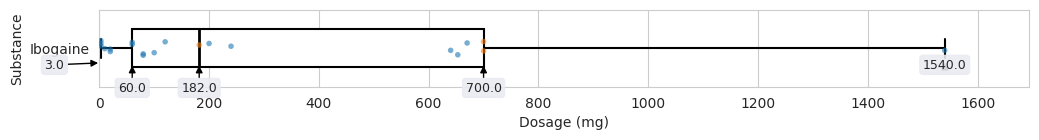

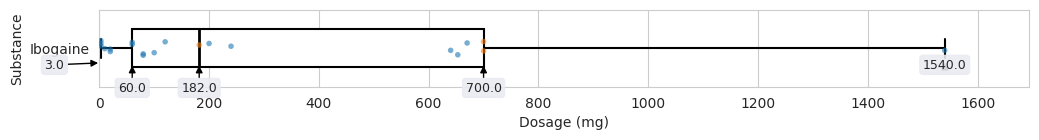

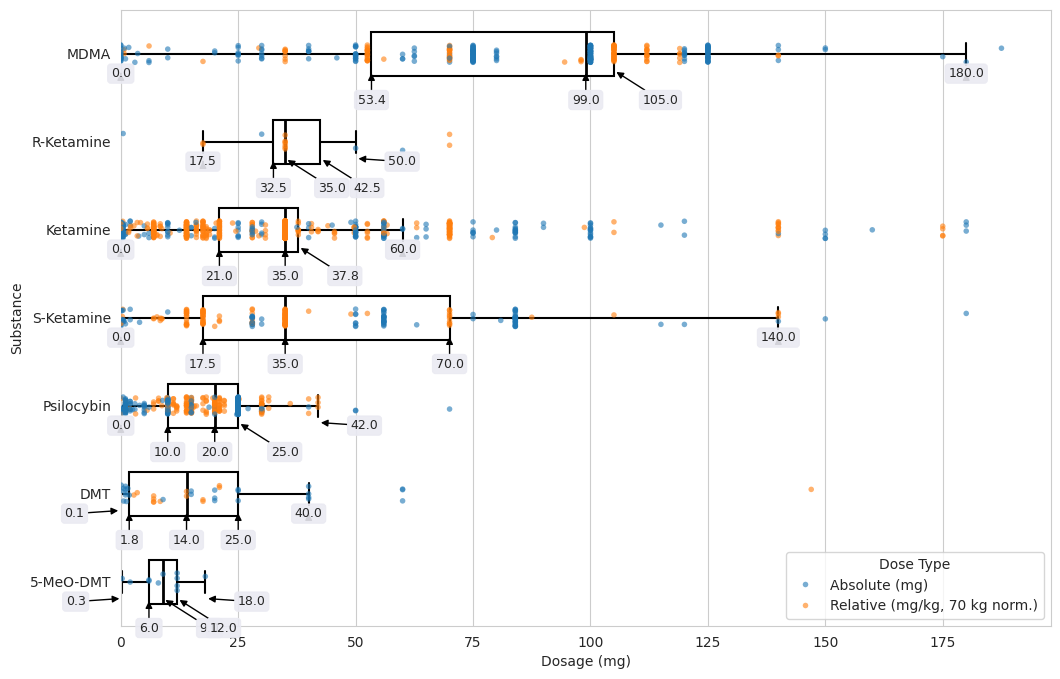

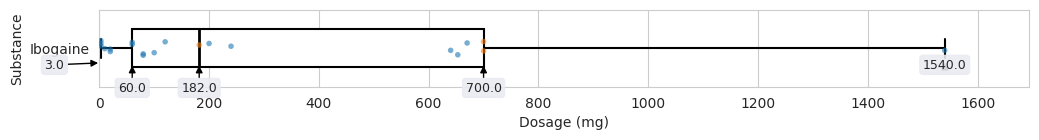

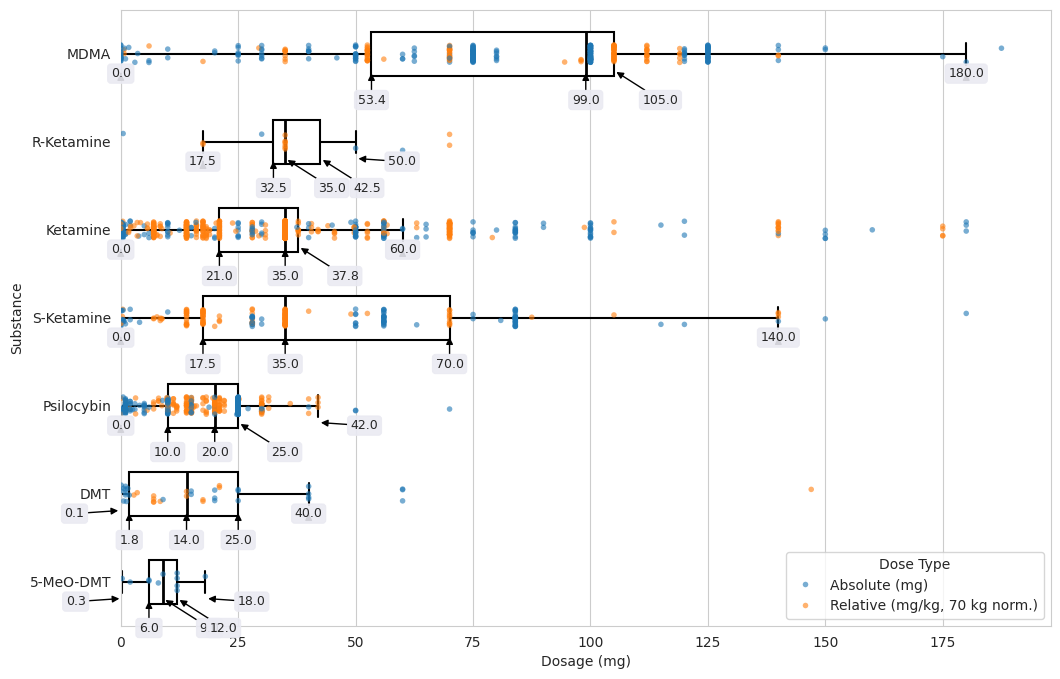

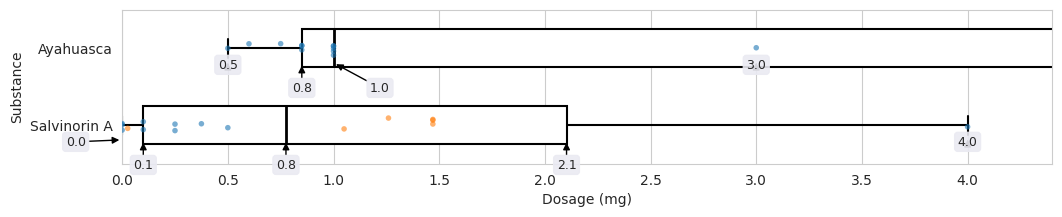

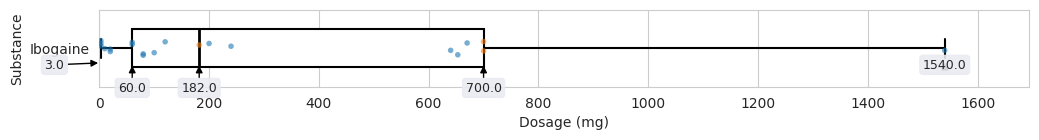

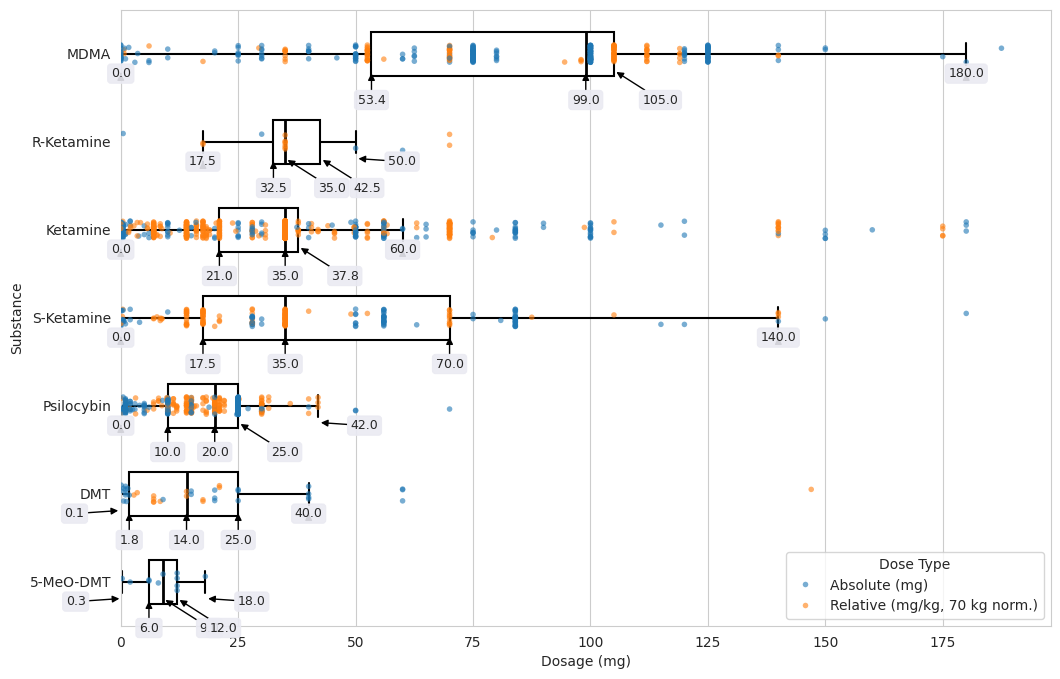

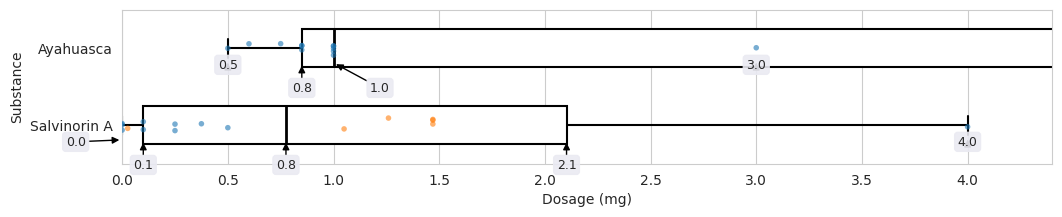

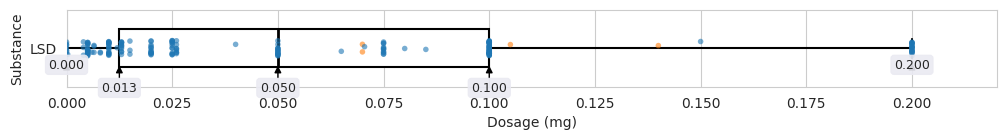

In [ ]:
make_fig(['Ibogaine'], 1, True)
substances = [
        'MDMA',
        'Ketamine',
        'S-Ketamine',
        'R-Ketamine',
        'Mescaline',
        'Ketamine',
        'Psilocybin',
        'DMT',
        '5-MeO-DMT',
       
    ]
make_fig(substances, 8)
make_fig(['Ayahuasca', 'Salvinorin A'], 2, True)
make_fig(['LSD'], 1, True, decimals=3)

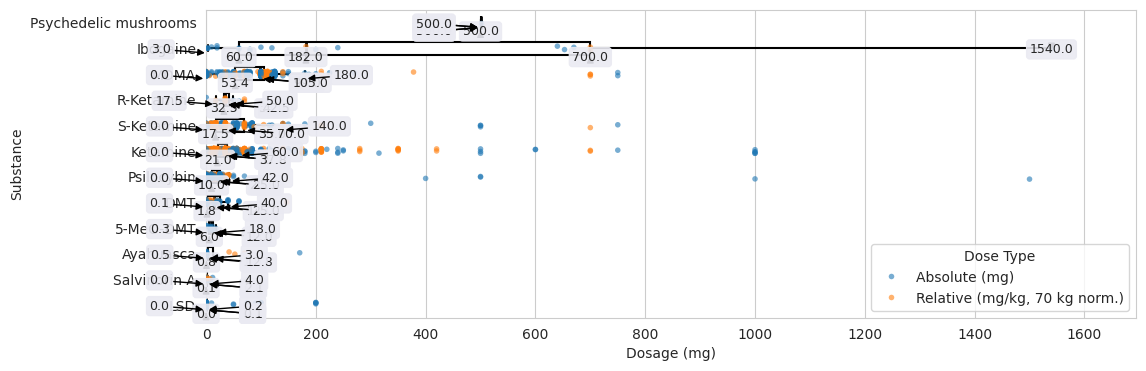

In [ ]:
make_fig()